In [ ]:
#!/usr/bin/env python3
"""
Comprehensive Topology Test: All Topologies on All Tasks

This script tests ALL topology types on ALL tasks using ALL three versions:

Topologies:
- Fully Connected
- Small World  
- Modular
- Hybrid

Tasks:
- CartPole-v1
- MountainCar-v0
- Acrobot-v1

Versions:
- Version A: Minimal Task Adapters (Universal approach)
- Version B: IO Padding/Truncation (Universal approach)  
- Version C: Single Task Direct (Simple approach)
- Standard MLP (Baseline comparison)

Total: 4 topologies × 3 tasks × 4 versions = 48 experiments
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import sys
import os
import time
from typing import Dict, List, Tuple, Any

# Add src to path
sys.path.append('src')

from src.topologies.fully_connected import FullyConnectedTopology
from src.topologies.small_world import SmallWorldTopology
from src.topologies.modular import ModularTopology
from src.topologies.hybrid import HybridTopology
from src.networks.ffn import FeedForwardNetwork

class TrainingCallback(BaseCallback):
    """Callback to track training metrics."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        
    def _on_step(self) -> bool:
        # Track episode rewards
        if len(self.training_env.buf_rews) > 0:
            self.current_episode_reward += self.training_env.buf_rews[0]
            self.current_episode_length += 1
            
            if self.training_env.buf_dones[0]:
                self.episode_rewards.append(self.current_episode_reward)
                self.episode_lengths.append(self.current_episode_length)
                self.current_episode_reward = 0
                self.current_episode_length = 0
        
        return True

class StandardMLPPolicy(ActorCriticPolicy):
    """Standard MLP policy for comparison."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Simple architecture matching the standard MLP
        self.shared_net = nn.Sequential(
            nn.Linear(self.features_dim, 64),  # Input → 64
            nn.ReLU(),
            nn.Linear(64, 64),                 # 64 → 64
            nn.ReLU(),
        )
        
        # Actor head (policy)
        self.action_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, action_space.n)      # 32 → action_dim
        )
        
        # Critic head (value)
        self.value_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, 1)                   # 32 → 1
        )
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.action_net(shared_features)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.value_net(shared_features)

# ============================================================================
# VERSION A: Minimal Task Adapters (Universal approach)
# ============================================================================

class MinimalAdapter(nn.Module):
    """Minimal adapter with configurable complexity."""
    
    def __init__(self, input_dim: int, output_dim: int, adapter_type: str = 'linear'):
        super().__init__()
        self.adapter_type = adapter_type
        
        if adapter_type == 'linear':
            # Simple linear projection
            self.projection = nn.Linear(input_dim, output_dim)
        elif adapter_type == 'tiny_mlp':
            # Tiny MLP with minimal hidden layer
            self.projection = nn.Sequential(
                nn.Linear(input_dim, 8),
                nn.ReLU(),
                nn.Linear(8, output_dim)
            )
        else:
            raise ValueError(f"Unknown adapter type: {adapter_type}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(x)

class VersionA_AdapterPolicy(ActorCriticPolicy):
    """Version A: Universal topology with minimal task adapters."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version A - {topology_type}] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version A - {topology_type}] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create minimal input adapter
        self.input_adapter = MinimalAdapter(
            self.task_input_dim, 
            self.universal_input_dim, 
            adapter_type='linear'
        )
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Create minimal output adapter
        self.output_adapter = MinimalAdapter(
            self.universal_output_dim, 
            self.task_output_dim, 
            adapter_type='linear'
        )
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with universal dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=total_size,
                num_layers=1,
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=total_size,
                k=4,
                p=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=total_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=total_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION B: IO Padding/Truncation (Universal approach)
# ============================================================================

class VersionB_PaddingPolicy(ActorCriticPolicy):
    """Version B: Universal topology with padding/truncation."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version B - {topology_type}] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version B - {topology_type}] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with universal dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=total_size,
                num_layers=1,
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=total_size,
                k=4,
                p=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=total_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=total_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def _pad_input(self, x: torch.Tensor) -> torch.Tensor:
        """Pad input from task dimension to universal dimension."""
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            # Pad with zeros
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            return torch.cat([x, padding], dim=1)
        else:
            # Truncate if needed
            return x[:, :self.universal_input_dim]
    
    def _truncate_output(self, x: torch.Tensor) -> torch.Tensor:
        """Truncate output from universal dimension to task dimension."""
        return x[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Pad input
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Truncate output
        task_output = self._truncate_output(universal_output)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Pad input
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Truncate output
        task_output = self._truncate_output(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION C: Single Task Direct (Simple approach)
# ============================================================================

class VersionC_DirectPolicy(ActorCriticPolicy):
    """Version C: Direct topology with task-specific dimensions."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Direct task dimensions
        self.input_dim = observation_space.shape[0]
        self.output_dim = action_space.n if hasattr(action_space, 'n') else action_space.shape[0]
        self.hidden_size = 64
        self.topology_type = topology_type
        
        print(f"[Version C - {topology_type}] Direct: {self.input_dim}→{self.output_dim}")
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n if hasattr(action_space, 'n') else action_space.shape[0])
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with direct task dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.input_dim + self.hidden_size + self.output_dim
        
        # Create topology based on type
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=total_size,
                num_layers=1,
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=total_size,
                k=4,
                p=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=total_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=total_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=1,
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.input_dim))
        output_nodes = list(range(self.input_dim + self.hidden_size, 
                                 self.input_dim + self.hidden_size + self.output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# TESTING FUNCTIONS
# ============================================================================

def test_policy(policy_class, policy_name, env_name, total_timesteps=100000):
    """Test a specific policy on a specific environment."""
    print(f"\n=== Testing {policy_name} on {env_name} ===")
    
    def make_env():
        return gym.make(env_name)
    
    env = DummyVecEnv([make_env])
    env = VecNormalize(env, norm_obs=True, norm_reward=False)
    
    # Adjust hyperparameters based on environment
    if env_name == 'CartPole-v1':
        learning_rate = 2e-4
        n_steps = 1024
    elif env_name == 'MountainCar-v0':
        learning_rate = 1e-3
        n_steps = 512
    elif env_name == 'Acrobot-v1':
        learning_rate = 1e-3
        n_steps = 512
    else:
        learning_rate = 2e-4
        n_steps = 1024
    
    model = PPO(
        policy_class,
        env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=64,
        n_epochs=4,
        gamma=0.99,
        clip_range=0.15,
        ent_coef=0.02,
        verbose=0
    )
    
    callback = TrainingCallback()
    start_time = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    training_time = time.time() - start_time
    
    # Test performance
    test_rewards = []
    for i in range(5):  # Reduced to 5 episodes for faster testing
        obs = env.reset()
        total_reward = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total_reward += reward[0]
            done = done[0]
        test_rewards.append(total_reward)
    
    avg_reward = np.mean(test_rewards)
    print(f"{policy_name} on {env_name} - Average test reward: {avg_reward:.2f}")
    print(f"{policy_name} on {env_name} - All test rewards: {test_rewards}")
    print(f"{policy_name} on {env_name} - Training time: {training_time:.1f}s")
    
    return {
        'policy': policy_name,
        'task': env_name,
        'avg_reward': avg_reward,
        'test_rewards': test_rewards,
        'episode_rewards': callback.episode_rewards,
        'training_time': training_time
    }

In [2]:

"""Run all experiments."""
print("🚀 Starting Comprehensive Topology Test")
print("=" * 80)
print("Testing: 4 topologies × 3 tasks × 4 versions = 48 experiments")
print("=" * 80)

# Define all experiments
experiments = [
    # Standard MLP on all tasks
    (StandardMLPPolicy, "Standard MLP", "CartPole-v1"),
    (StandardMLPPolicy, "Standard MLP", "MountainCar-v0"),
    (StandardMLPPolicy, "Standard MLP", "Acrobot-v1"),
    
    # Version A (Adapters) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version A - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version A - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version A - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionA_AdapterPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version A - hybrid", "Acrobot-v1"),
    
    # Version B (Padding) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version B - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version B - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version B - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionB_PaddingPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version B - hybrid", "Acrobot-v1"),
    
    # Version C (Direct) on all topologies and tasks
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C - fully_connected", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C - small_world", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C - modular", "CartPole-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C - hybrid", "CartPole-v1"),
    
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C - fully_connected", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C - small_world", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C - modular", "MountainCar-v0"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C - hybrid", "MountainCar-v0"),
    
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='fully_connected', **kwargs), 
        "Version C - fully_connected", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='small_world', **kwargs), 
        "Version C - small_world", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='modular', **kwargs), 
        "Version C - modular", "Acrobot-v1"),
    (lambda obs, act, lr, **kwargs: VersionC_DirectPolicy(obs, act, lr, topology_type='hybrid', **kwargs), 
        "Version C - hybrid", "Acrobot-v1"),
]

🚀 Starting Comprehensive Topology Test
Testing: 4 topologies × 3 tasks × 4 versions = 48 experiments


In [3]:
# Run all experiments
results = []
for i, (policy_class, policy_name, env_name) in enumerate(experiments):
    print(f"\n🔄 Progress: {i+1}/{len(experiments)} ({((i+1)/len(experiments)*100):.1f}%)")
    try:
        result = test_policy(policy_class, policy_name, env_name)
        results.append(result)
    except Exception as e:
        print(f"❌ Error in {policy_name} on {env_name}: {e}")
        continue


🔄 Progress: 1/39 (2.6%)

=== Testing Standard MLP on CartPole-v1 ===


Output()

Output()

Standard MLP on CartPole-v1 - Average test reward: 500.00
Standard MLP on CartPole-v1 - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0]
Standard MLP on CartPole-v1 - Training time: 236.6s

🔄 Progress: 2/39 (5.1%)

=== Testing Standard MLP on MountainCar-v0 ===


Output()

...

Output()

Version C - small_world on Acrobot-v1 - Average test reward: -500.00
Version C - small_world on Acrobot-v1 - All test rewards: [-500.0, -500.0, -500.0, -500.0, -500.0]
Version C - small_world on Acrobot-v1 - Training time: 134.1s

🔄 Progress: 38/39 (97.4%)

=== Testing Version C - modular on Acrobot-v1 ===
[Version C - modular] Direct: 6→3


Output()

Version C - modular on Acrobot-v1 - Average test reward: -97.00
Version C - modular on Acrobot-v1 - All test rewards: [-77.0, -77.0, -163.0, -94.0, -74.0]
Version C - modular on Acrobot-v1 - Training time: 170.2s

🔄 Progress: 39/39 (100.0%)

=== Testing Version C - hybrid on Acrobot-v1 ===
[Version C - hybrid] Direct: 6→3


Version C - hybrid on Acrobot-v1 - Average test reward: -92.60
Version C - hybrid on Acrobot-v1 - All test rewards: [-115.0, -71.0, -89.0, -86.0, -102.0]
Version C - hybrid on Acrobot-v1 - Training time: 166.5s


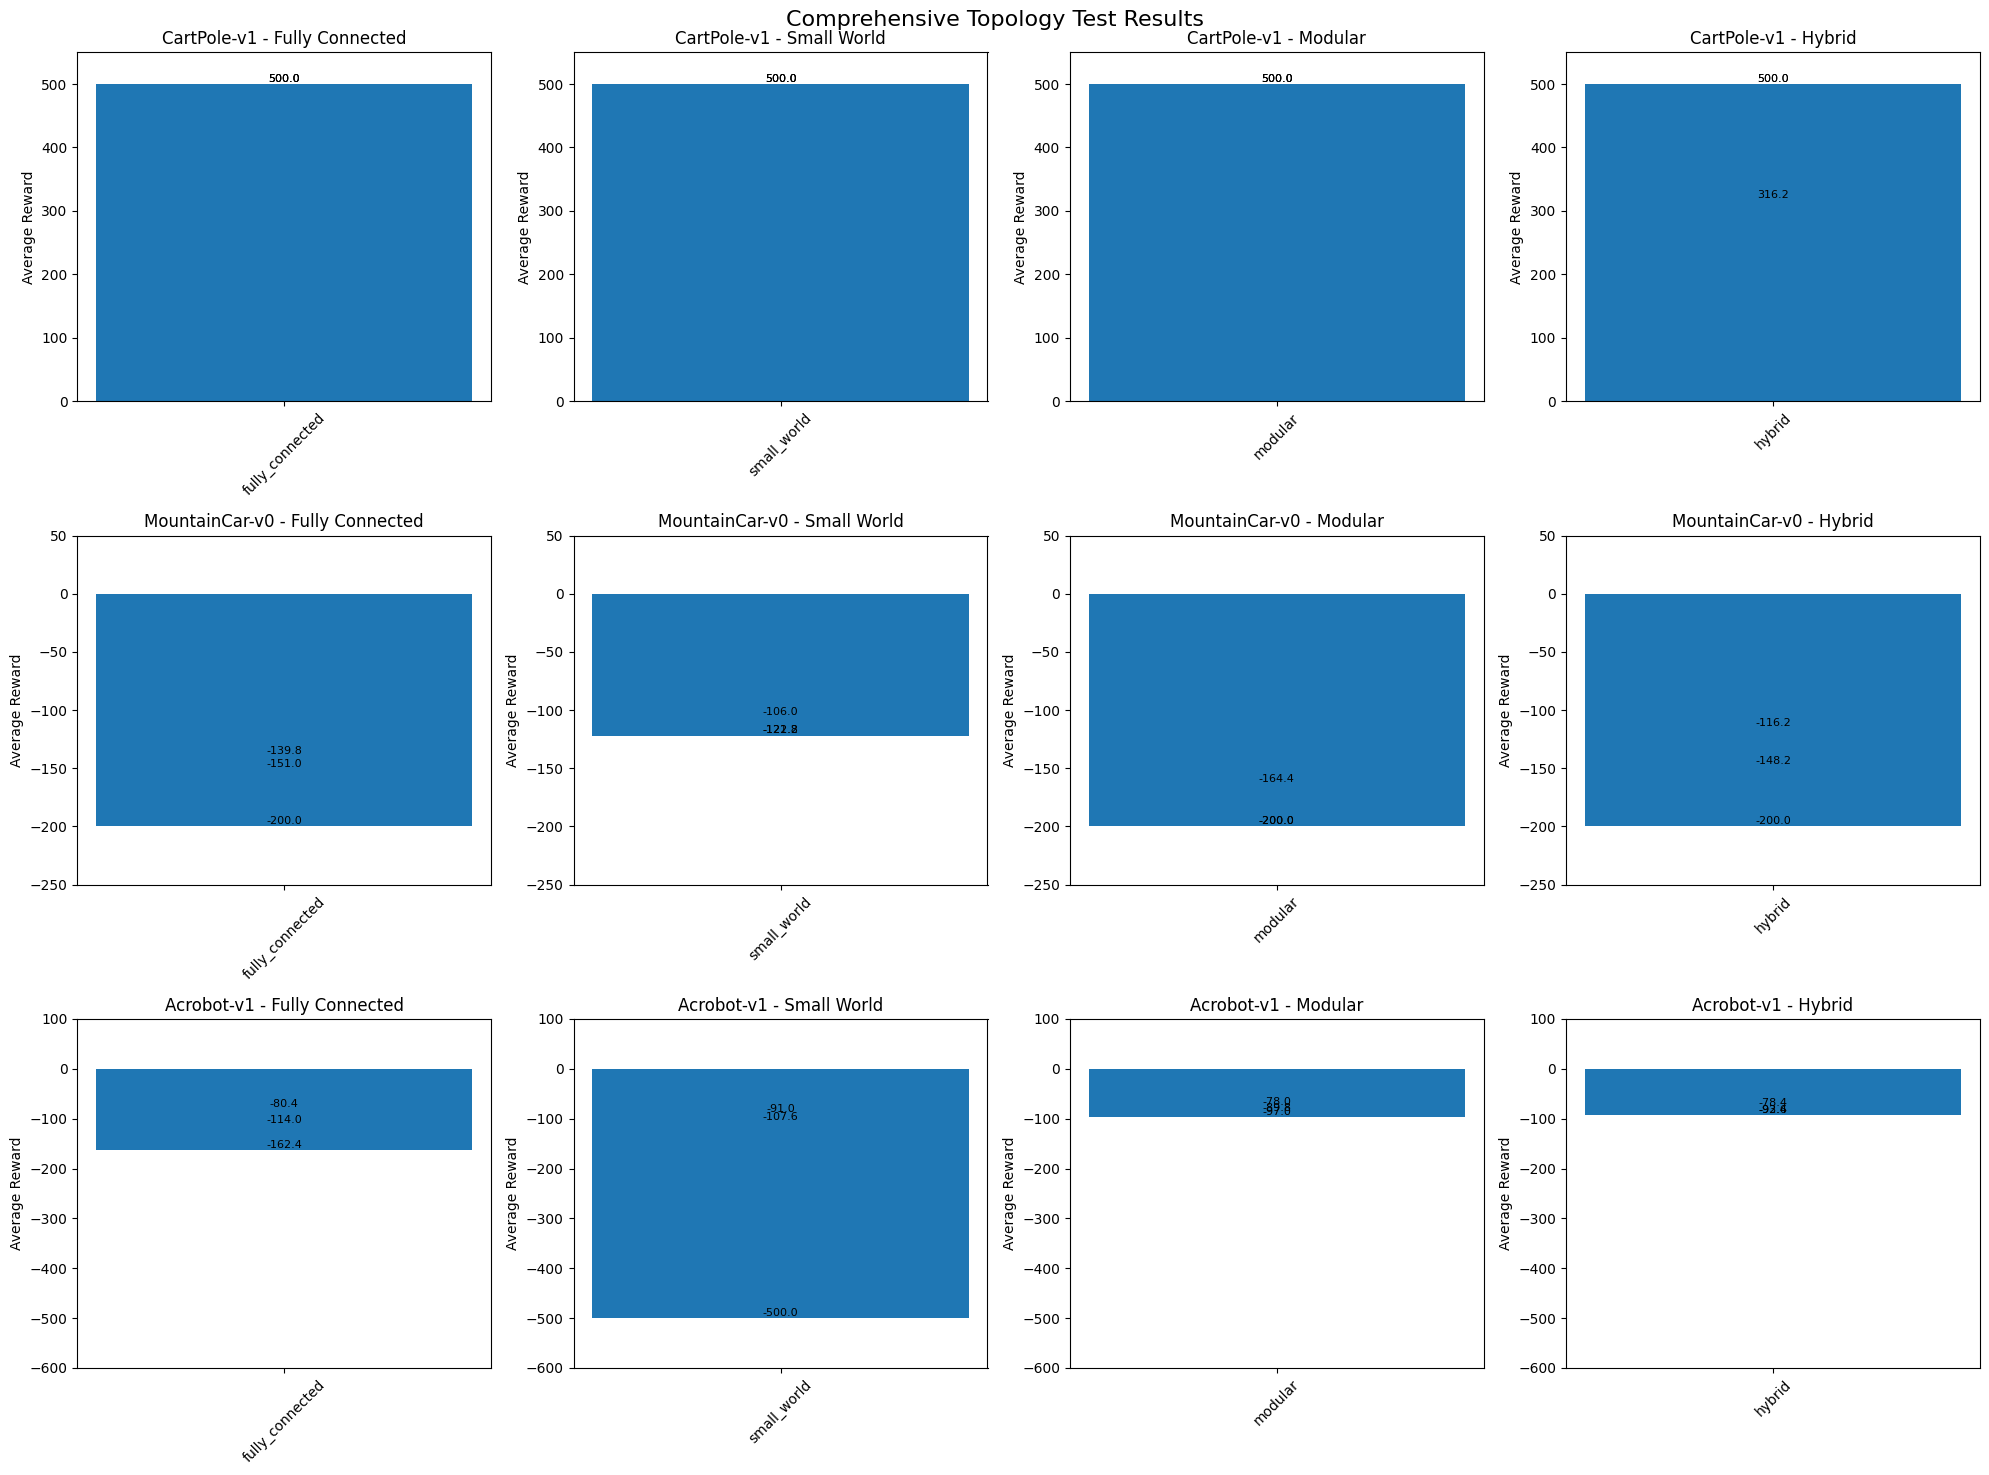

In [4]:

"""Plot comprehensive results for all experiments."""
# Organize results by task
tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']
topologies = ['fully_connected', 'small_world', 'modular', 'hybrid']
versions = ['Standard MLP', 'Version A: Adapters', 'Version B: Padding', 'Version C: Direct']

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Comprehensive Topology Test Results', fontsize=16)

for task_idx, task in enumerate(tasks):
    for topo_idx, topology in enumerate(topologies):
        ax = axes[task_idx, topo_idx]
        
        # Get results for this task and topology
        task_results = []
        for result in results:
            if result['task'] == task and topology in result['policy']:
                task_results.append(result)
        
        if task_results:
            # Plot average rewards
            avg_rewards = [r['avg_reward'] for r in task_results]
            policy_names = [r['policy'].split(' - ')[-1] if ' - ' in r['policy'] else r['policy'] for r in task_results]
            
            bars = ax.bar(policy_names, avg_rewards)
            ax.set_title(f'{task} - {topology.replace("_", " ").title()}')
            ax.set_ylabel('Average Reward')
            ax.tick_params(axis='x', rotation=45)
            
            # Add value labels on bars
            for bar, reward in zip(bars, avg_rewards):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                        f'{reward:.1f}', ha='center', va='bottom', fontsize=8)
            
            # Set y-axis limits based on task
            if task == 'CartPole-v1':
                ax.set_ylim(0, 550)
            elif task == 'MountainCar-v0':
                ax.set_ylim(-250, 50)
            elif task == 'Acrobot-v1':
                ax.set_ylim(-600, 100)

plt.tight_layout()
plt.savefig('comprehensive_topology_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
"""Create a summary table of all results."""
print("\n" + "=" * 100)
print("📊 COMPREHENSIVE RESULTS SUMMARY")
print("=" * 100)

# Organize by task
tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']

for task in tasks:
    print(f"\n🎯 {task.upper()}")
    print("-" * 80)
    print(f"{'Topology':<15} {'Version':<20} {'Avg Reward':<12} {'Min':<8} {'Max':<8} {'Time(s)':<8}")
    print("-" * 80)
    
    task_results = [r for r in results if r['task'] == task]
    task_results.sort(key=lambda x: (x['policy'], x['avg_reward']), reverse=True)
    
    for result in task_results:
        topology = result['policy'].split(' - ')[0] if ' - ' in result['policy'] else 'Standard MLP'
        version = result['policy'].split(' - ')[-1] if ' - ' in result['policy'] else 'Standard MLP'
        avg_reward = result['avg_reward']
        min_reward = min(result['test_rewards'])
        max_reward = max(result['test_rewards'])
        training_time = result['training_time']
        
        print(f"{topology:<15} {version:<20} {avg_reward:<12.2f} {min_reward:<8.0f} {max_reward:<8.0f} {training_time:<8.1f}")


📊 COMPREHENSIVE RESULTS SUMMARY

🎯 CARTPOLE-V1
--------------------------------------------------------------------------------
Topology        Version              Avg Reward   Min      Max      Time(s) 
--------------------------------------------------------------------------------
Version C       small_world          500.00       500      500      149.5   
Version C       modular              500.00       500      500      154.0   
Version C       hybrid               500.00       500      500      157.2   
Version C       fully_connected      500.00       500      500      144.0   
Version B       small_world          500.00       500      500      81.2    
Version B       modular              500.00       500      500      76.4    
Version B       hybrid               500.00       500      500      76.3    
Version B       fully_connected      500.00       500      500      76.9    
Version A       small_world          500.00       500      500      224.5   
Version A       modu